# 병렬 처리 워크플로 구현하기: 날씨, 뉴스, 주식 병렬 처리

In [1]:
# 왜 병렬 처리 필요?
# LLM 호출 실행, API 호출, DB 접근, 파일 처리...  <- 처리시간이 오래 걸리는 작업
# 이런작업들은 '순차적'으로 실행하면 느리다!
# 병렬로 '동시'에 실행하여 워크플로의 성능을 극대화.

# 랭그래프는 각 노드들을 '독립적'으로 실행 할수도 있다!
# 다른 노드에 의존성이 없는 노드는 자동적으로 병렬 실행 할수 있게 됩니다


![](https://www.dropbox.com/scl/fi/9b0e4awbcu748dscpsokk/de261a80-b7e8-4195-bdb2-bac3e0b613f7.png?rlkey=j9crwzsc7xi8snvtua7gypv7w&st=f4au96u1&dl=1)
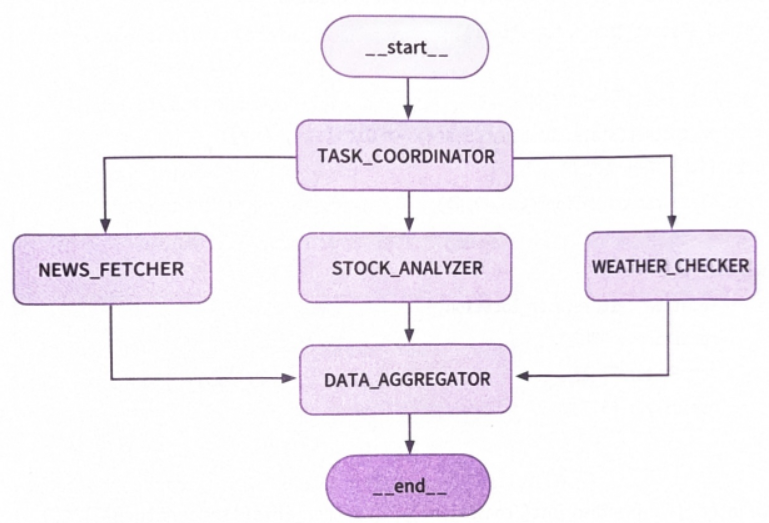

![](https://www.dropbox.com/scl/fi/gm5kc8v2w3hgme09okizd/f526f915-e1d5-4bbe-ad20-c5a7ec7b9f80.png?rlkey=e2wdd841abtjx2493p0pj9sqq&st=j6vu43ys&dl=1)
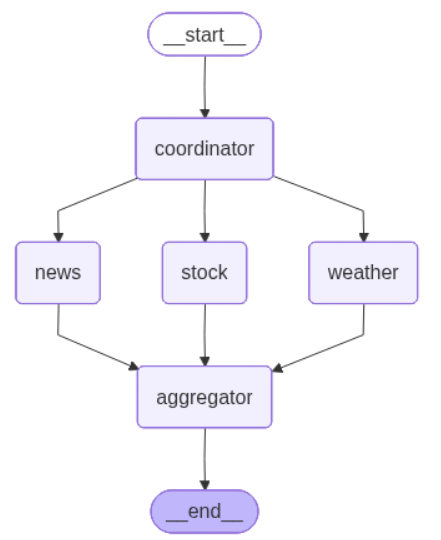

# import

In [2]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Dict, Any
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
import time
import random
from IPython.display import Image, display

True


# 상태정의

In [3]:
# ① State 클래스 정의
class DashboardState(BaseModel):
    user_location: str = "서울"  # 사용자의 위치
    weather_data: Dict[str, Any] = {}  # 날씨 데이터
    news_data: Dict[str, Any] = {}   # 뉴스 데이터
    stock_data: Dict[str, Any] = {}  # 주식 관련 데이터
    dashboard_report: str = ""   # 대시보드 리포트
    start_time: float = 0.0   # 대시보드 생성시각

# coordinator 노드
- 병렬처리의 시작점 역할
- `시작시간`을 업데이트 하여 전체 실행 시간 측정에 사용할거다.

In [4]:
# ② 코디네이터 노드
def coordinator(state: DashboardState) -> Dict[str, Any]:
    print(f"🟦 대시보드 생성 시작 - 위치: {state.user_location}")
    return {"start_time": time.time()}  # 그래프에 시작시간 업데이트

# 병렬 실행할 노드(들)

In [5]:
# ③ 병렬 실행 노드 1 - 날씨 데이터 수집
def weather_checker(state: DashboardState) -> Dict[str, Any]:
    print("🌐날씨 확인 중...")
    time.sleep(random.uniform(1.0, 2.0))  # 딜레이

    weather_info = {
        "location": state.user_location,
        "condition": "맑음",
        "temperature": 22,
        "humidity": 65,
    }
    
    print(f"🌐날씨: {weather_info['condition']} {weather_info['temperature']}°C")
    return {"weather_data": weather_info}

In [6]:
# ④ 병렬 실행 노드 2 - 뉴스 데이터 수집
def news_fetcher(state: DashboardState) -> Dict[str, Any]:
    print("🎃뉴스 수집 중...")
    time.sleep(random.uniform(1.5, 2.5))  # 

    news_info = {
        "articles": [
            {"title": "AI 기술 발전 소식", "summary": "AI 분야 새로운 혁신"},
            {"title": "경제 동향 분석", "summary": "글로벌 경제 전망"},
        ],
        "count": 2,
    }

    print(f"🎃뉴스 {news_info['count']}개 수집 완료")
    return {"news_data": news_info}

In [7]:
# ⑤ 병렬 실행 노드 3 - 주식 데이터 분석
def stock_analyzer(state: DashboardState) -> Dict[str, Any]:
    print("💦주식 분석 중...")
    time.sleep(random.uniform(2.0, 3.0))  # 

    stock_info = {
        "KOSPI": {"price": 4650.5, "change": +1.2},
        "NASDAQ": {"price": 15780.3, "change": -0.8},
    }

    print("💦주식 분석 완료")
    return {"stock_data": stock_info}

# aggregator(집계)노드

In [8]:
# 집계 노드: '모든' 병렬 실행 노드들의 작업이 끝나면 집계 노드로 가게 됩니다. 
# 수집된 데이터를 종합하여 리포트를 생성합니다. 전체 실행 시간을 계산합니다.


In [9]:
# ⑥ 집계 노드 - 모든 병렬 작업 완료 후 실행
def aggregator(state: DashboardState) -> Dict[str, Any]:
    print("✅ 리포트 생성 중...")

    elapsed_time = time.time() - state.start_time  # 실행 시간 측정

    report = f"""
대시보드 리포트
날씨: {state.weather_data.get("condition", "N/A")} {state.weather_data.get("temperature", "N/A")}°C
뉴스: {state.news_data.get("count", 0)}개 기사
주식: KOSPI {state.stock_data.get("KOSPI", {}).get("price", "N/A")}
실행시간: {elapsed_time:.1f}초
"""

    print(f"✅ 대시보드 완료 ({elapsed_time:.1f}초)")
    return {"dashboard_report": report}

# 그래프 정의

In [10]:
def create_graph():
    workflow = StateGraph(DashboardState)

    # ⑦ 노드 추가
    #  : 시작을 위한 coordinator() 노드, 
    #  : 병렬 처리를 위한 weather_checker(), news_fetcher(), stock_analyzer() 노드, 
    #  : 집계를 위한 aggregator()노드를 그래프에 추가합니다.
    workflow.add_node("coordinator", coordinator)
    workflow.add_node("weather", weather_checker)
    workflow.add_node("news", news_fetcher)
    workflow.add_node("stock", stock_analyzer)
    workflow.add_node("aggregator", aggregator)

    # ⑧ 병렬 실행 구조 정의
    # : coordinator()에서 weather_checker(). news_fetcher(), stock_analyzer()로 3개의 에지를 연결합니다. 
    # 또한 각 병렬 처리 노드에서 aggregator()로 다시 연결을 합니다.
    workflow.add_edge(START, 'coordinator')
    
    # "coordinator" 실행후 weather, news, stock 이 병렬실행
    workflow.add_edge("coordinator", "weather")
    workflow.add_edge("coordinator", "news")
    workflow.add_edge("coordinator", "stock")

    # weather, news, stock 이 '모두 실행된 뒤'에 aggregator 실행
    workflow.add_edge("weather", "aggregator")
    workflow.add_edge("news", "aggregator")
    workflow.add_edge("stock", "aggregator")
    
    workflow.add_edge("aggregator", END)

    return workflow.compile()


# 실행

=== LangGraph 병렬 실행 예제 ===

병렬 실행 시작!
🟦 대시보드 생성 시작 - 위치: 부산
🎃뉴스 수집 중...
💦주식 분석 중...
🌐날씨 확인 중...
🌐날씨: 맑음 22°C
🎃뉴스 2개 수집 완료
💦주식 분석 완료
✅ 리포트 생성 중...
✅ 대시보드 완료 (3.0초)

최종 결과:

대시보드 리포트
날씨: 맑음 22°C
뉴스: 2개 기사
주식: KOSPI 4650.5
실행시간: 3.0초



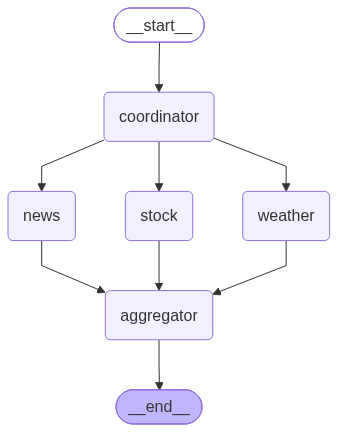

In [11]:
def main():
    print("=== LangGraph 병렬 실행 예제 ===\n")

    app = create_graph()
    initial_state = DashboardState(user_location='부산')

    print("병렬 실행 시작!")
    # ⑨ 워크플로우 실행: invoke() 메서드를 사용해서 전체 워크플로를 실행합니다. 
    #   병렬 처리는 랭그래프가 알아서 관리해줍니다.
    result = app.invoke(initial_state)

    print("\n최종 결과:")
    print(result['dashboard_report'])

    # 그래프 시각화
    display(Image(app.get_graph().draw_mermaid_png()))

if __name__ == "__main__":
    main()
